# Исследование структуры коммуникационной сети

В рамках данной работы проводится анализ коммуникационной сети, представленной в виде графовой структуры.

Исходные данные отражают обмен сообщениями между участниками, связанными с морской инфраструктурой, портовой деятельностью и операционным управлением.  
Коммуникации включают обсуждение перемещения судов, согласование разрешений, координацию действий экипажей, мониторинг активности и административные процедуры.

Сеть представлена в виде ориентированного графа, где:

- узлы соответствуют участникам коммуникации (организациям, должностным лицам, службам)
- рёбра отражают факт отправки сообщения от одного участника другому
- сообщения содержат текстовую информацию, позволяющую анализировать тематическую направленность взаимодействий

Таким образом, сеть отражает информационные потоки внутри операционной системы, связанной с управлением морской деятельностью и взаимодействием различных служб.

Цель исследования — выявить особенности организации коммуникаций, определить ключевых участников, структуру взаимодействий и тематическую направленность сообщений.

Анализ включает:

- преобразование графа в плоскую структуру данных
- временной анализ активности
- исследование сетевых метрик
- выявление сообществ
- анализ межкластерных связей
- содержательный анализ сообщений

## Гипотезы исследования

H1: Коммуникационная сеть имеет выраженное центральное ядро с несколькими доминирующими участниками

H2: Сеть сегментирована на устойчивые сообщества с преобладанием внутригрупповых взаимодействий

H3: Ключевые посредники соединяют различные кластеры и обеспечивают межгрупповую коммуникацию

H4: Тематика сообщений различается между крупнейшими сообществами и отражает функциональную специализацию групп

## 1. Загрузка и первичный анализ структуры графа

Данные представлены в формате JSON и содержат:

- список узлов (nodes),
- список связей (edges),
- служебную информацию о типе графа.

На данном этапе проводится первичный анализ структуры данных для понимания состава сущностей и типов связей

In [14]:
import json
import pandas as pd

with open("MC3_graph.json", "r") as f:
    data = json.load(f)

data.keys()

dict_keys(['directed', 'multigraph', 'graph', 'nodes', 'edges'])

Граф содержит два ключевых элемента:

- nodes - список сущностей
- edges - список связей между сущностями

Для дальнейшего анализа преобразуем их в плоский (табличный) формат

In [15]:
nodes = pd.DataFrame(data["nodes"])
edges = pd.DataFrame(data["edges"])

nodes.head()

,type,label,name,sub_type,id,timestamp,monitoring_type,findings,content,assessment_type,...,friendship_type,permission_type,start_date,end_date,report_type,submission_date,jurisdiction_type,authority_level,coordination_type,operational_role
0,Entity,Sam,Sam,Person,Sam,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Entity,Kelly,Kelly,Person,Kelly,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Entity,Nadia Conti,Nadia Conti,Person,Nadia Conti,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Entity,Elise,Elise,Person,Elise,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Entity,Liam Thorne,Liam Thorne,Person,Liam Thorne,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Анализ типов сущностей

Для понимания структуры графа необходимо определить, какие типы объектов в нём представлены

In [16]:
nodes["sub_type"].value_counts()

sub_type
Communication       584
Coordinates          74
Monitoring           70
AccessPermission     68
VesselMovement       46
Operates             40
Assessment           36
Colleagues           30
Location             29
Suspicious           28
Collaborate          25
Reports              25
Enforcement          21
Person               18
Vessel               15
TourActivity         13
Jurisdiction         13
Unfriendly            5
Organization          5
Group                 5
TransponderPing       3
Friends               2
HarborReport          2
Fishing               1
Criticize             1
Name: count, dtype: int64

Анализ показывает, что граф содержит:

- сущности типа Person (участники коммуникаций)
- Vessel (суда)
- Communication (сообщения)
- а также различные типы событий (Monitoring, Assessment, VesselMovement и др.)

Особый интерес для дальнейшего анализа представляют узлы типа Communication, так как они содержат временную информацию и текст сообщений

## 3. Анализ типов связей

Следующим шагом является изучение типов связей между сущностями

In [17]:
edges["type"].value_counts()

type
evidence_for    1036
sent             584
received         584
Name: count, dtype: int64

Основные типы связей:

- sent - отправка сообщения
- received - получение сообщения
- evidence_for - связь сообщения с событием или выводом

Таким образом, коммуникация представлена как отдельная сущность, связанная с отправителем и получателем через рёбра

## 4. Преобразование графовой структуры в плоскую таблицу сообщений

Для проведения временного анализа и анализа активности участников необходимо преобразовать графовую структуру в табличную форму, где каждая строка соответствует одному сообщению

Из графа извлекаются:

- узлы типа Communication
- отправители (связь sent)
- получатели (связь received)
- временные метки сообщений

In [18]:
communications = nodes[nodes["sub_type"] == "Communication"].copy()

sent_edges = edges[edges["type"] == "sent"][["source", "target"]]
sent_edges.rename(columns={"source":"sender", "target":"comm_id"}, inplace=True)

received_edges = edges[edges["type"] == "received"][["source", "target"]]
received_edges.rename(columns={"source":"comm_id", "target":"receiver"}, inplace=True)

messages = sent_edges.merge(received_edges, on="comm_id", how="left")
messages = messages.merge(
    communications.set_index("id"),
    left_on="comm_id",
    right_index=True,
    how="left"
)

messages.head()

,sender,comm_id,receiver,type,label,name,sub_type,timestamp,monitoring_type,findings,...,friendship_type,permission_type,start_date,end_date,report_type,submission_date,jurisdiction_type,authority_level,coordination_type,operational_role
0,Sam,Event_Communication_370,Kelly,Event,Communication,NaN,Communication,2040-10-05 10:48:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Kelly,Event_Communication_3,Sam,Event,Communication,NaN,Communication,2040-10-01 08:13:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Kelly,Event_Communication_443,Sam,Event,Communication,NaN,Communication,2040-10-07 08:11:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Nadia Conti,Event_Communication_331,Haacklee Harbor,Event,Communication,NaN,Communication,2040-10-05 09:45:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Nadia Conti,Event_Communication_334,Oceanus City Council,Event,Communication,NaN,Communication,2040-10-05 09:49:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


В результате была получена плоская таблица сообщений, содержащая:

- отправителя
- получателя
- временную метку
- текст сообщения
- дополнительные атрибуты события

Данное представление значительно упрощает дальнейший анализ временных паттернов и активности участников

## 5. Временной анализ коммуникаций

После преобразования графовой структуры в плоскую таблицу сообщений становится возможным анализ временных характеристик коммуникации

Цель данного этапа:

- выявить суточные закономерности активности  
- определить пики коммуникаций  
- проанализировать изменения интенсивности сообщений во времени  

In [19]:
messages["datetime"] = pd.to_datetime(messages["timestamp"])

messages["datetime"].min(), messages["datetime"].max()

(Timestamp('2040-10-01 08:09:00'), Timestamp('2040-10-14 13:35:00'))

Данные охватывают период наблюдений продолжительностью около двух недель

Это позволяет анализировать как суточные паттерны, так и изменения активности во времени

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid")

# создаём полный диапазон часов
all_hours = pd.DataFrame({"hour": np.arange(0, 24)})

hour_counts = (
    messages["hour"]
    .value_counts()
    .sort_index()
    .reset_index()
)

hour_counts.columns = ["hour", "count"]

# объединяем, чтобы добавить нули для отсутствующих часов
hour_counts = all_hours.merge(hour_counts, on="hour", how="left")
hour_counts["count"] = hour_counts["count"].fillna(0)

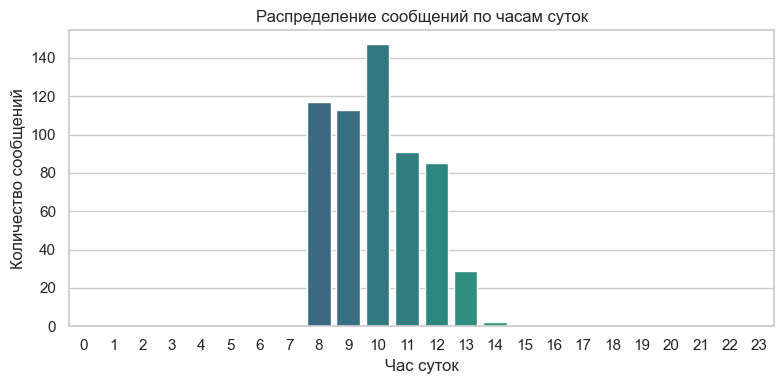

In [49]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=hour_counts,
    x="hour",
    y="count",
    hue="hour",
    palette="viridis",
    legend=False
)

plt.title("Распределение сообщений по часам суток")
plt.xlabel("Час суток")
plt.ylabel("Количество сообщений")

plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

### Выводы

Активность коммуникаций сосредоточена в утренние часы

Пик наблюдается около 10 часов

Отсутствие сообщений в ночное время может свидетельствовать о планируемом характере коммуникации

In [38]:
messages["date"] = messages["datetime"].dt.date

daily_counts = (
    messages
    .groupby("date")
    .size()
    .reset_index(name="count")
)

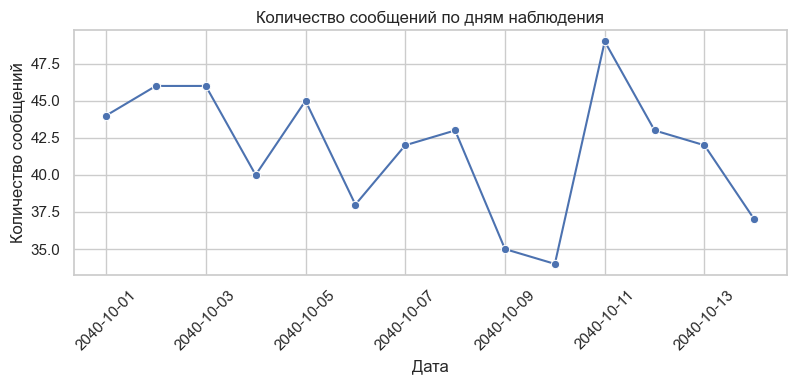

In [48]:
plt.figure(figsize=(8,4))

sns.lineplot(
    data=daily_counts,
    x="date",
    y="count",
    marker="o"
)

plt.title("Количество сообщений по дням наблюдения")
plt.xlabel("Дата")
plt.ylabel("Количество сообщений")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Выводы

Активность коммуникаций в целом остаётся относительно стабильной в течение всего периода наблюдения

Количество сообщений варьируется в диапазоне примерно от 34 до 49 в день

Наиболее низкая активность наблюдается 9–10 октября

Резкий пик фиксируется 11 октября, что может свидетельствовать о значимом событии или координации действий

После 11 октября наблюдается постепенное снижение интенсивности коммуникаций

Резких долгосрочных трендов роста или падения активности не выявлено

In [40]:
pivot = messages.pivot_table(
    index="date",
    columns="hour",
    aggfunc="size",
    fill_value=0
)

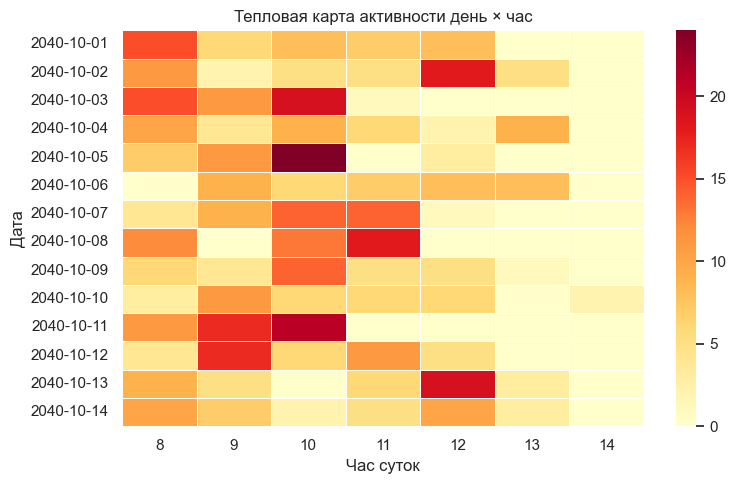

In [47]:
plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Тепловая карта активности день × час")
plt.xlabel("Час суток")
plt.ylabel("Дата")

plt.tight_layout()
plt.show()

### Выводы

Коммуникационная активность сосредоточена преимущественно в утренние часы с 8 до 12

Наиболее выраженные пики наблюдаются около 10 часов

Пиковые значения повторяются в разные дни, что указывает на регулярный характер взаимодействия

11 октября фиксируется особенно высокая концентрация сообщений в утренние часы

После 12–13 часов активность существенно снижается, что подтверждает структурированный временной характер коммуникации

Ночное и вечернее взаимодействие отсутствует

### Дополнительное сравнение между буднями и выходными

Дополнительно исследуется распределение коммуникационной активности между будними и выходными днями.

Цель анализа — определить, связана ли интенсивность обмена сообщениями с рабочими днями и существуют ли различия в паттернах коммуникации.

In [93]:
communications["timestamp"] = pd.to_datetime(communications["timestamp"])

communications["weekday"] = communications["timestamp"].dt.day_name()
communications["is_weekend"] = communications["timestamp"].dt.weekday >= 5

In [94]:
weekend_activity = (
    communications
    .groupby("is_weekend")
    .size()
    .reset_index(name="message_count")
)

weekend_activity["day_type"] = weekend_activity["is_weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

weekend_activity

,is_weekend,message_count,day_type
0,False,425,Weekday
1,True,159,Weekend


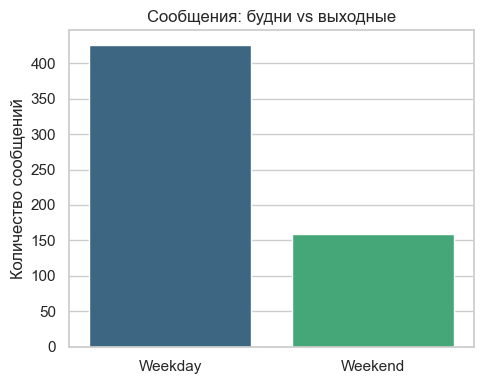

In [95]:
plt.figure(figsize=(5,4))

sns.barplot(
    data=weekend_activity,
    x="day_type",
    y="message_count",
    hue="day_type",
    palette="viridis",
    legend=False
)

plt.title("Сообщения: будни vs выходные")
plt.xlabel("")
plt.ylabel("Количество сообщений")

plt.tight_layout()
plt.show()

### Выводы

Наблюдается явный паттерн уменьшения количества сообщений в выходные, что свидетельствует об операционном характере взаимодействий

### Общий вывод по временному анализу

Коммуникационная активность в рассматриваемый период носит регулярный и структурированный характер

Сообщения преимущественно отправляются в утренние часы с выраженным пиком около 10 часов

Вечерняя и ночная активность практически отсутствует, что указывает на организованный формат взаимодействия и рабочий характер коммуникаций

По дням наблюдается относительная стабильность количества сообщений без выраженного долгосрочного тренда роста или снижения

Отдельные всплески активности, например 11 октября, могут свидетельствовать о событиях, требующих более интенсивной координации между участниками

Дополнительный анализ будних и выходных дней показывает заметное снижение активности в выходные  
Основной объём сообщений приходится на рабочие дни, что подтверждает связь коммуникаций с операционной и административной деятельностью

В целом коммуникации выглядят планируемыми, сосредоточенными в рабочие часы и в основном происходят в будние дни

## 6. Анализ активности участников

После изучения временной динамики коммуникаций проводится анализ структуры взаимодействия между участниками

Цель этапа:

- определить наиболее активных отправителей  
- выявить наиболее часто упоминаемых получателей  
- оценить распределение коммуникационной нагрузки  
- определить возможных центральных участников сети  

In [42]:
top_senders = (
    messages["sender"]
    .value_counts()
    .reset_index()
)

top_senders.columns = ["sender", "count"]

top_senders.head(10)

,sender,count
0,Green Guardians,44
1,Oceanus City Council,37
2,Mako,35
3,Reef Guardian,34
4,Neptune,34
5,The Lookout,33
6,Himark Harbor,27
7,Remora,25
8,Davis,25
9,The Intern,24


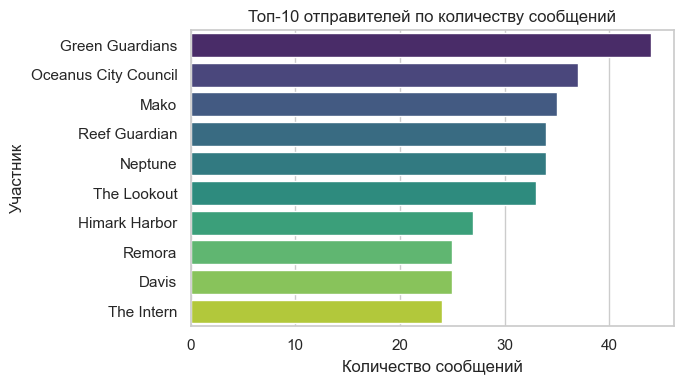

In [44]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=top_senders.head(10),
    y="sender",
    x="count",
    hue="sender",
    palette="viridis",
    legend=False
)

plt.title("Топ-10 отправителей по количеству сообщений")
plt.xlabel("Количество сообщений")
plt.ylabel("Участник")

plt.tight_layout()
plt.show()

### Выводы

Наиболее активным отправителем является Green Guardians

Высокую активность также демонстрируют Oceanus City Council и Mako

В числе лидеров присутствуют как организации, так и отдельные участники, что указывает на смешанный характер коммуникационной структуры

Активность распределена относительно равномерно среди нескольких ключевых акторов, явного единоличного доминирования не наблюдается

The Intern входит в топ-10 отправителей, что может свидетельствовать о его значимой роли в координации или передаче информации

In [50]:
top_receivers = (
    messages["receiver"]
    .value_counts()
    .reset_index()
)

top_receivers.columns = ["receiver", "count"]

top_receivers.head(10)

,receiver,count
0,Mako,58
1,Oceanus City Council,45
2,Remora,37
3,Reef Guardian,28
4,Green Guardians,27
5,Neptune,26
6,Mrs. Money,24
7,Sentinel,23
8,Horizon,22
9,Boss,21


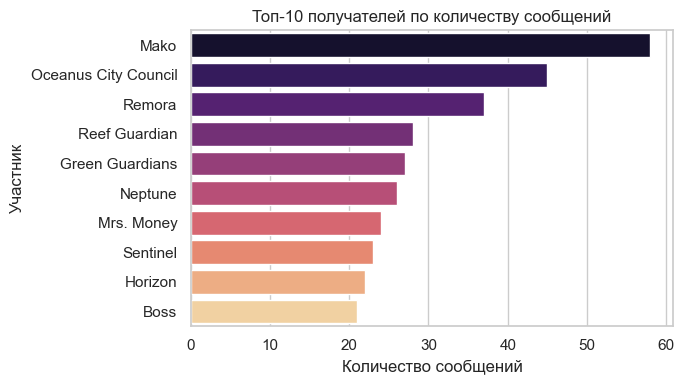

In [51]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=top_receivers.head(10),
    y="receiver",
    x="count",
    hue="receiver",
    palette="magma",
    legend=False
)

plt.title("Топ-10 получателей по количеству сообщений")
plt.xlabel("Количество сообщений")
plt.ylabel("Участник")

plt.tight_layout()
plt.show()

### Выводы

Наиболее часто получателем сообщений выступает Mako

Высокую долю входящих сообщений также имеют Oceanus City Council и Remora

В списке получателей появляются участники, отсутствующие среди лидеров по отправке, например Mrs. Money и Boss

Это может свидетельствовать о централизованной передаче информации к отдельным ключевым фигурам

Наблюдается асимметрия коммуникации: некоторые участники чаще получают сообщения, чем отправляют их

### Общий вывод по анализу активности участников

Структура коммуникаций указывает на наличие нескольких центральных акторов

Mako и Oceanus City Council занимают важные позиции как по отправке, так и по получению сообщений

Green Guardians демонстрируют высокую исходящую активность, что может указывать на координирующую роль

Наличие асимметрии между отправкой и получением сообщений требует дальнейшего анализа баланса коммуникации

## 7. Баланс коммуникации и центральные участники

Для выявления потенциальных центров влияния необходимо сопоставить количество отправленных и полученных сообщений для каждого участника

Это позволит:

- определить наиболее вовлечённых акторов  
- выявить асимметрию коммуникации  
- обнаружить возможные координационные центры  

In [52]:
sent_counts = messages["sender"].value_counts()
received_counts = messages["receiver"].value_counts()

activity = pd.DataFrame({
    "sent": sent_counts,
    "received": received_counts
}).fillna(0)

activity["total"] = activity["sent"] + activity["received"]
activity["balance"] = activity["sent"] - activity["received"]

activity = activity.sort_values("total", ascending=False)

activity.head(10)

,sent,received,total,balance
Mako,35.0,58.0,93.0,-23.0
Oceanus City Council,37.0,45.0,82.0,-8.0
Green Guardians,44.0,27.0,71.0,17.0
Remora,25.0,37.0,62.0,-12.0
Reef Guardian,34.0,28.0,62.0,6.0
Neptune,34.0,26.0,60.0,8.0
Himark Harbor,27.0,18.0,45.0,9.0
Davis,25.0,18.0,43.0,7.0
Mrs. Money,19.0,24.0,43.0,-5.0
The Intern,24.0,18.0,42.0,6.0


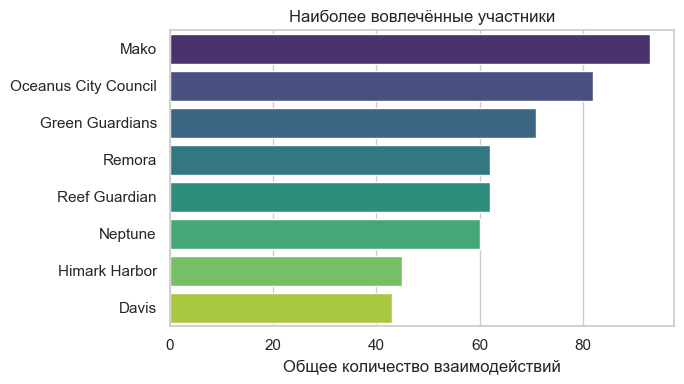

In [53]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=activity.head(8).reset_index(),
    y="index",
    x="total",
    hue="index",
    palette="viridis",
    legend=False
)

plt.title("Наиболее вовлечённые участники")
plt.xlabel("Общее количество взаимодействий")
plt.ylabel("")

plt.tight_layout()
plt.show()

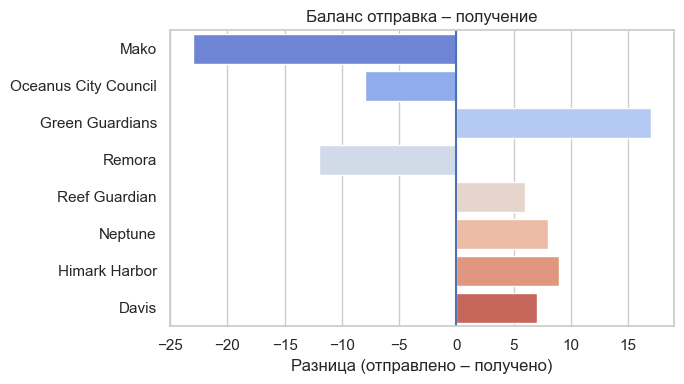

In [54]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=activity.head(8).reset_index(),
    y="index",
    x="balance",
    hue="index",
    palette="coolwarm",
    legend=False
)

plt.axvline(0)
plt.title("Баланс отправка – получение")
plt.xlabel("Разница (отправлено – получено)")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Вывод по анализу вовлечённости и баланса коммуникации

Наиболее вовлечённым участником сети является Mako, имеющий максимальное суммарное количество взаимодействий

Высокую активность также демонстрируют Oceanus City Council и Green Guardians, что указывает на их ключевую роль в коммуникационной структуре

Анализ баланса отправки и получения сообщений показывает выраженную асимметрию для ряда участников

Green Guardians имеют положительный баланс, что свидетельствует о более высокой исходящей активности и потенциальной координирующей роли

Mako и Remora характеризуются отрицательным балансом, что указывает на преобладание входящих сообщений и возможную роль получателей или центров принятия решений

Oceanus City Council демонстрирует относительно сбалансированную коммуникацию, что может говорить о двустороннем характере взаимодействия

Таким образом, структура сети предполагает наличие нескольких центров влияния с различными функциями: координация, получение информации и распределение задач

## 8. Анализ структуры взаимодействий

На данном этапе исследуется направленная структура коммуникаций между участниками

Цель анализа:

- определить наиболее частые пары отправитель–получатель  
- выявить устойчивые каналы коммуникации  
- подготовить основу для выявления групп и кластеров  

In [56]:
pair_counts = (
    messages
    .groupby(["sender", "receiver"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

pair_counts.head(10)

,sender,receiver,count
4,Clepper Jensen,Miranda Jordan,20
90,Miranda Jordan,Clepper Jensen,18
193,The Intern,Mrs. Money,15
201,The Lookout,The Intern,12
34,Green Guardians,Oceanus City Council,12
30,Green Guardians,Green Guardians,12
111,Neptune,Remora,9
153,Remora,Mako,9
113,Neptune,V. Miesel Shipping,8
121,Oceanus City Council,Liam Thorne,8


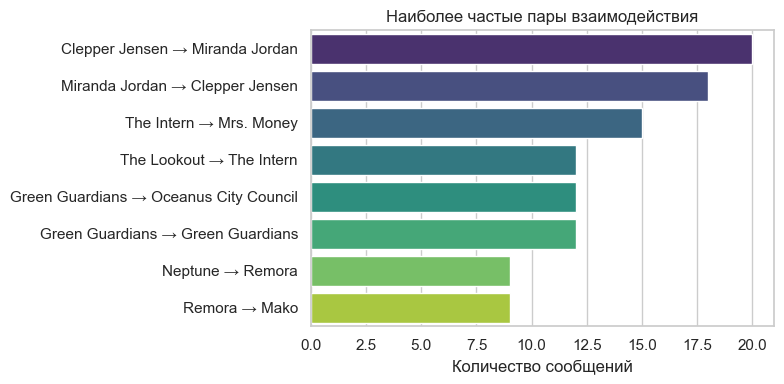

In [57]:
top_pairs = pair_counts.head(8).copy()
top_pairs["pair"] = top_pairs["sender"] + " → " + top_pairs["receiver"]

plt.figure(figsize=(8,4))

sns.barplot(
    data=top_pairs,
    y="pair",
    x="count",
    hue="pair",
    palette="viridis",
    legend=False
)

plt.title("Наиболее частые пары взаимодействия")
plt.xlabel("Количество сообщений")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [58]:
interaction_matrix = messages.pivot_table(
    index="sender",
    columns="receiver",
    aggfunc="size",
    fill_value=0
)

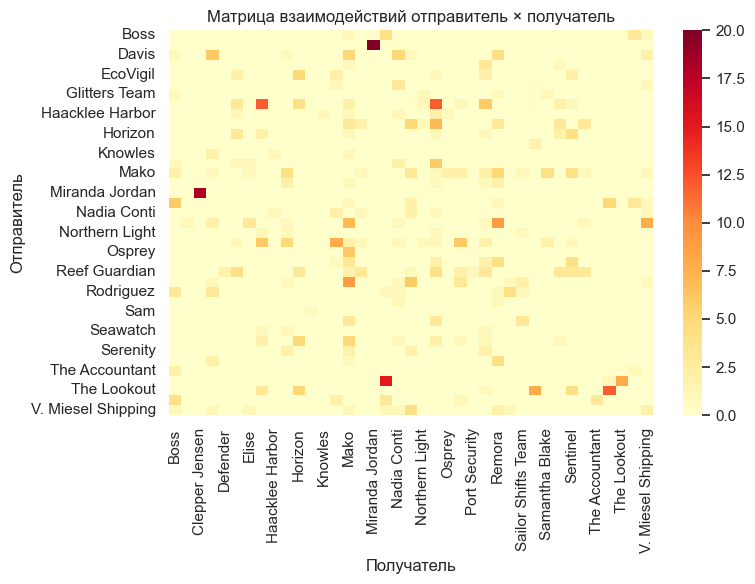

In [59]:
plt.figure(figsize=(8,6))

sns.heatmap(
    interaction_matrix,
    cmap="YlOrRd"
)

plt.title("Матрица взаимодействий отправитель × получатель")
plt.xlabel("Получатель")
plt.ylabel("Отправитель")

plt.tight_layout()
plt.show()

### Вывод по анализу структуры взаимодействий

Анализ наиболее частых пар показывает наличие устойчивых двусторонних связей

Наиболее интенсивное взаимодействие наблюдается между Clepper Jensen и Miranda Jordan, причём коммуникация носит взаимный характер

Также выделяются устойчивые каналы The Intern → Mrs. Money и The Lookout → The Intern, что может указывать на иерархическую цепочку передачи информации

Взаимодействие Green Guardians с Oceanus City Council демонстрирует регулярный характер и может отражать институциональные контакты

Матрица взаимодействий подтверждает, что коммуникация распределена неравномерно

Наблюдаются отдельные концентрированные ячейки с повышенной интенсивностью, тогда как большинство связей имеют низкую частоту

Это свидетельствует о наличии ядра сети с устойчивыми каналами связи при общей разреженности структуры

В целом коммуникационная сеть имеет выраженные центры притяжения и повторяющиеся направленные потоки информации

## 9. Сетевой анализ коммуникационной сети

На данном этапе коммуникации рассматриваются как ориентированный граф

Цель анализа:

- определить наиболее влиятельных участников  
- выявить посредников между группами  
- количественно оценить центральность акторов  

In [62]:
import networkx as nx

G = nx.from_pandas_edgelist(
    messages,
    source="sender",
    target="receiver",
    create_using=nx.DiGraph()
)

print("Количество узлов:", G.number_of_nodes())
print("Количество рёбер:", G.number_of_edges())

Количество узлов: 41
Количество рёбер: 217


In [63]:
degree_centrality = nx.degree_centrality(G)
degree_df = (
    pd.Series(degree_centrality, name="degree_centrality")
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "participant"})
)

degree_df.head(10)

,participant,degree_centrality
0,Mako,0.925
1,Oceanus City Council,0.700
2,Reef Guardian,0.675
3,Remora,0.525
4,Neptune,0.475
5,V. Miesel Shipping,0.475
6,Green Guardians,0.425
7,Nadia Conti,0.425
8,Himark Harbor,0.425
9,Sentinel,0.400


In [64]:
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

degree_balance = pd.DataFrame({
    "participant": list(G.nodes()),
    "in_degree": [in_degree[n] for n in G.nodes()],
    "out_degree": [out_degree[n] for n in G.nodes()]
})

degree_balance["total_degree"] = (
    degree_balance["in_degree"] + degree_balance["out_degree"]
)

degree_balance.sort_values("total_degree", ascending=False).head(10)

,participant,in_degree,out_degree,total_degree
14,Mako,21,16,37
4,Oceanus City Council,15,13,28
27,Reef Guardian,14,13,27
16,Remora,12,9,21
6,Neptune,9,10,19
8,V. Miesel Shipping,9,10,19
26,Green Guardians,7,10,17
2,Nadia Conti,11,6,17
17,Himark Harbor,9,8,17
24,Sentinel,8,8,16


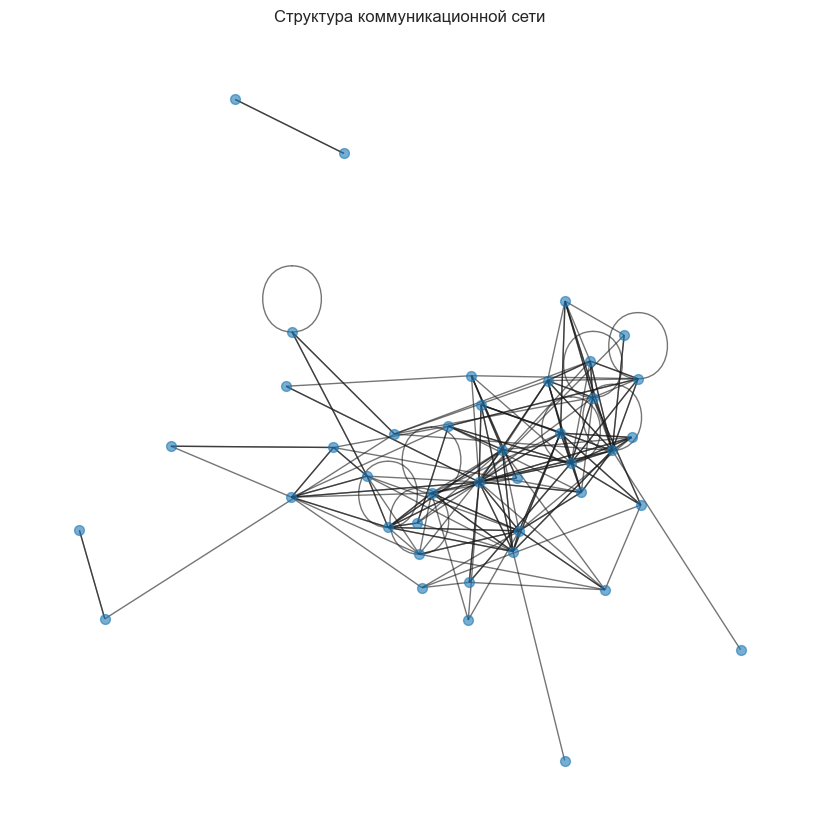

In [74]:
plt.figure(figsize=(8,8))

pos = nx.spring_layout(G, k=0.5)

nx.draw(
    G,
    pos,
    node_size=50,
    with_labels=False,
    arrows=False,
    alpha=0.6
)

plt.title("Структура коммуникационной сети")
plt.show()

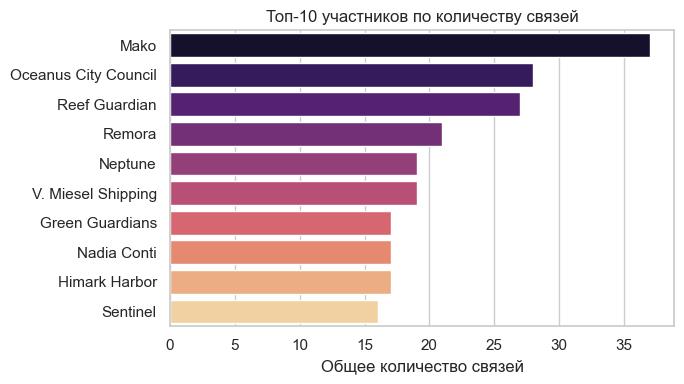

In [65]:
top_degree = degree_balance.sort_values(
    "total_degree", ascending=False
).head(10)

plt.figure(figsize=(7,4))

sns.barplot(
    data=top_degree,
    y="participant",
    x="total_degree",
    hue="participant",
    palette="magma",
    legend=False
)

plt.title("Топ-10 участников по количеству связей")
plt.xlabel("Общее количество связей")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [66]:
betweenness = nx.betweenness_centrality(G)

betweenness_df = (
    pd.Series(betweenness, name="betweenness")
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "participant"})
)

betweenness_df.head(10)

,participant,betweenness
0,Mako,0.236217
1,Mrs. Money,0.107165
2,Reef Guardian,0.089543
3,Boss,0.087297
4,V. Miesel Shipping,0.076091
5,Nadia Conti,0.075559
6,Oceanus City Council,0.074428
7,The Intern,0.066147
8,Remora,0.057984
9,Neptune,0.052941


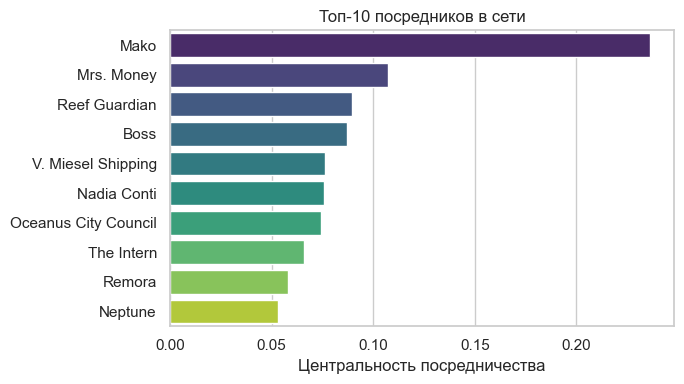

In [67]:
top_bet = betweenness_df.head(10)

plt.figure(figsize=(7,4))

sns.barplot(
    data=top_bet,
    y="participant",
    x="betweenness",
    hue="participant",
    palette="viridis",
    legend=False
)

plt.title("Топ-10 посредников в сети")
plt.xlabel("Центральность посредничества")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Дополнительно визуализация графа с другими layout

Чтобы лучше понять структуру сети, полезно сравнить разные способы размещения узлов (layout)

Дополнительно размер узлов зададим пропорционально количеству связей, чтобы визуально подчеркнуть центральных участников

In [96]:
G_plot = G.to_undirected()

deg = dict(G_plot.degree())
max_deg = max(deg.values()) if len(deg) else 1

# масштабирование размеров
node_sizes = [80 + 520 * (deg[n] / max_deg) for n in G_plot.nodes()]

In [97]:
def draw_graph_layout(G, pos, title, node_sizes):
    plt.figure(figsize=(8,8))
    
    nx.draw_networkx_edges(G, pos, alpha=0.35, width=1.0)
    nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        alpha=0.85
    )
    
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

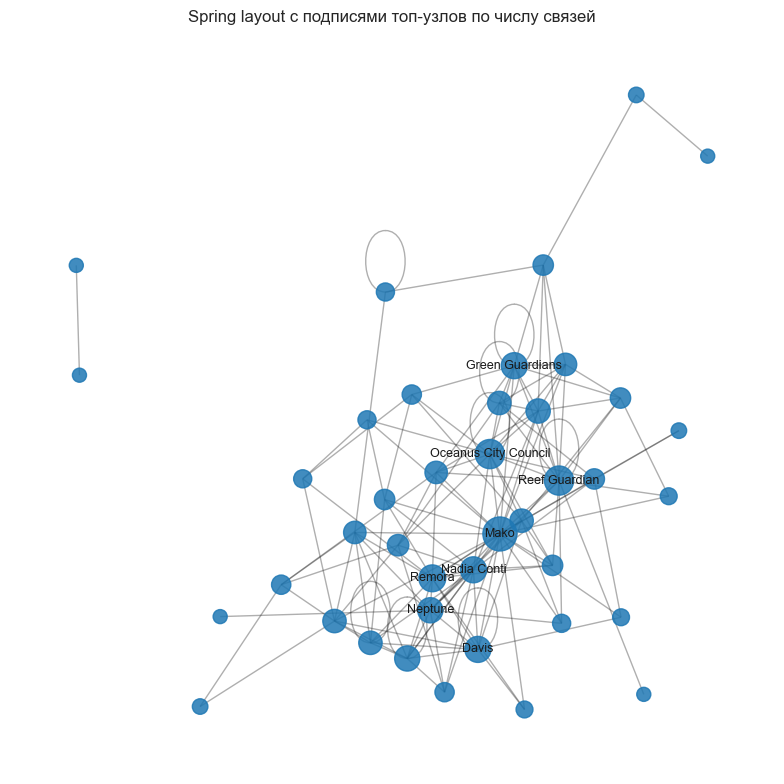

In [103]:
top_nodes = sorted(deg, key=deg.get, reverse=True)[:8]
labels = {n: n for n in top_nodes}

plt.figure(figsize=(8,8))
nx.draw_networkx_edges(G_plot, pos_spring, alpha=0.35, width=1.0)
nx.draw_networkx_nodes(G_plot, pos_spring, node_size=node_sizes, alpha=0.85)
nx.draw_networkx_labels(G_plot, pos_spring, labels=labels, font_size=9)

plt.title("Spring layout с подписями топ-узлов по числу связей")
plt.axis("off")
plt.tight_layout()
plt.show()

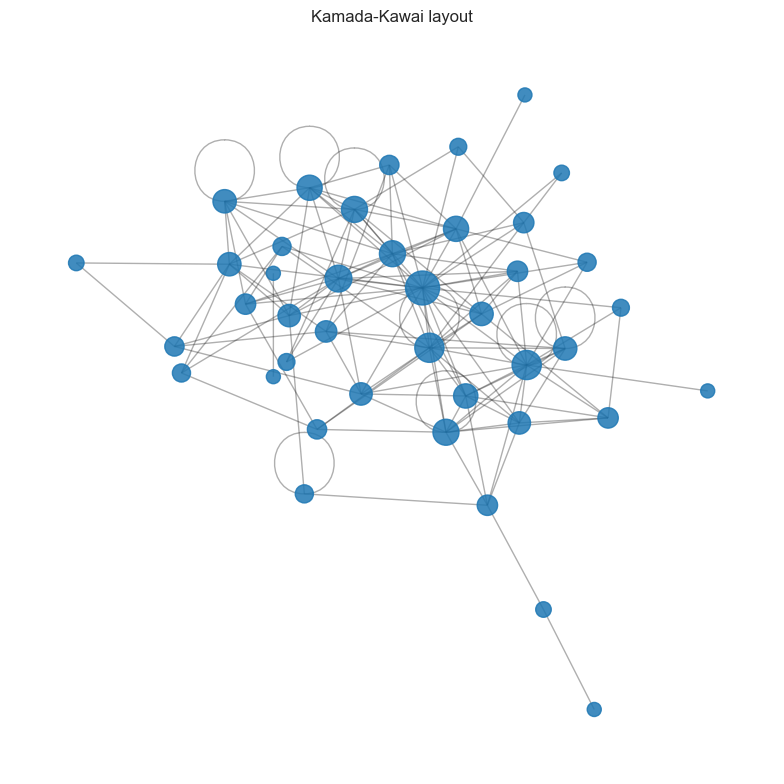

In [99]:
pos_kk = nx.kamada_kawai_layout(G_plot)
draw_graph_layout(G_plot, pos_kk, "Kamada-Kawai layout", node_sizes)

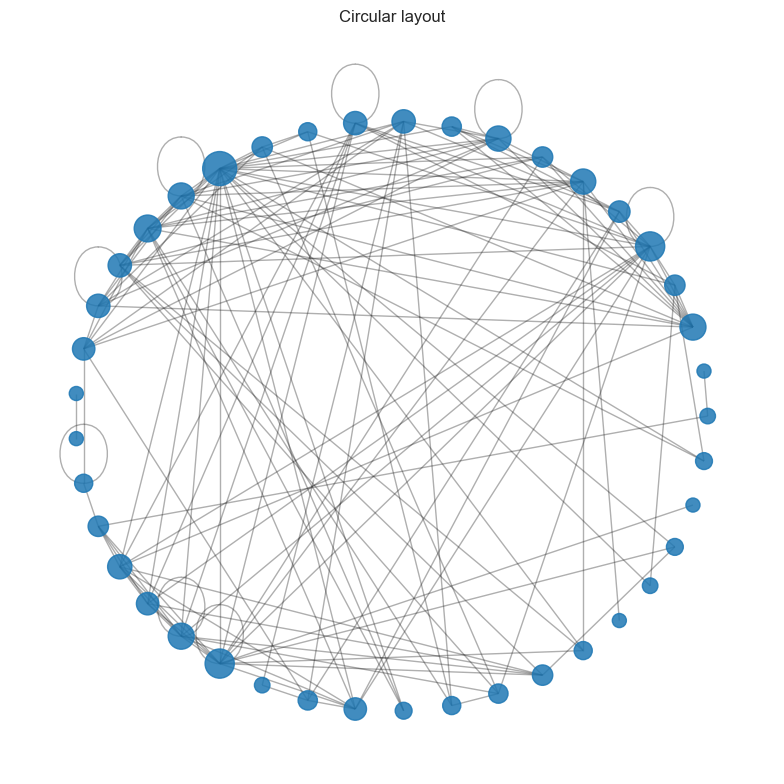

In [100]:
pos_circ = nx.circular_layout(G_plot)
draw_graph_layout(G_plot, pos_circ, "Circular layout", node_sizes)

#### Вывод по дополнительным визуализациям графа

Сравнение различных способов размещения узлов позволяет лучше рассмотреть структуру сети

Spring и Kamada–Kawai layout показывают наличие плотного центрального ядра, в котором сосредоточено большинство участников и коммуникационных связей

Увеличение размера узлов пропорционально числу связей позволяет визуально выделить наиболее активных участников сети  
Крупные узлы расположены преимущественно в центре графа, что подтверждает их ключевую роль в коммуникационной структуре

Circular layout показывает общий уровень связности сети и демонстрирует большое количество перекрёстных взаимодействий между участниками

В совокупности разные layout подтверждают наличие центральной группы участников, вокруг которой формируется основная часть коммуникаций

### Вывод по сетевому анализу коммуникационной структуры

Визуализация графа показывает сеть с выраженным плотным ядром

Большинство участников сосредоточены в центральном кластере, где наблюдается высокая плотность связей  
При этом присутствуют периферийные узлы и отдельные слабосвязанные компоненты, которые имеют ограниченное число взаимодействий с остальной сетью

Сравнение различных layout графа подтверждает данную структуру  
Независимо от способа размещения узлов центральная часть сети остаётся наиболее плотной и содержит участников с наибольшим числом связей

Анализ степени центральности показывает, что Mako является наиболее связанным участником сети  
Он имеет наибольшее количество коммуникационных связей и занимает центральное положение в структуре графа

Oceanus City Council и Reef Guardian также входят в число наиболее интегрированных участников  
Это указывает на их значительную роль в обмене информацией внутри сети

Анализ центральности посредничества показывает, что Mako выступает ключевым связующим элементом между различными частями сети  
Высокие значения посредничества у Mrs. Money, Reef Guardian и Boss указывают на их роль как промежуточных звеньев в передаче информации

Таким образом коммуникационная сеть носит умеренно централизованный характер  
Основная часть взаимодействий сосредоточена вокруг группы центральных участников, которые формируют ядро сети и обеспечивают связность между различными группами

## 10. Анализ сообществ

На данном этапе исследуется наличие кластеров внутри коммуникационной сети

Цель анализа:

- выявить группы участников с плотными внутренними связями  
- определить возможные коалиции  
- проверить гипотезу о сегментации сети  

In [75]:
from networkx.algorithms.community import greedy_modularity_communities

# Для алгоритма используем неориентированный граф
G_undirected = G.to_undirected()

communities = list(greedy_modularity_communities(G_undirected))

print("Количество выявленных сообществ:", len(communities))

Количество выявленных сообществ: 5


In [76]:
community_map = {}

for i, community in enumerate(communities):
    for node in community:
        community_map[node] = i

community_df = pd.DataFrame({
    "participant": list(community_map.keys()),
    "community": list(community_map.values())
})

community_df.head()

,participant,community
0,Davis,0
1,Nadia Conti,0
2,Neptune,0
3,Elise,0
4,Himark Harbor,0


In [77]:
community_sizes = (
    community_df["community"]
    .value_counts()
    .sort_index()
    .reset_index()
)

community_sizes.columns = ["community", "size"]
community_sizes

,community,size
0,0,16
1,1,12
2,2,7
3,3,4
4,4,2


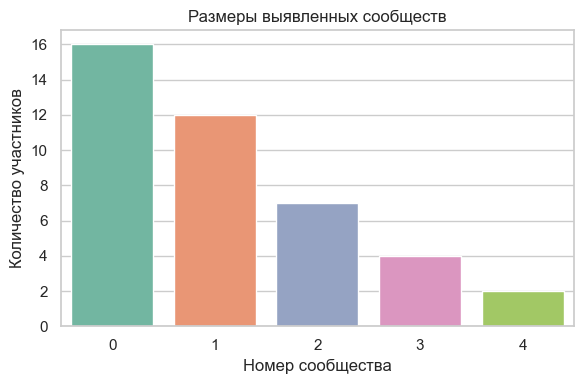

In [78]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=community_sizes,
    x="community",
    y="size",
    hue="community",
    palette="Set2",
    legend=False
)

plt.title("Размеры выявленных сообществ")
plt.xlabel("Номер сообщества")
plt.ylabel("Количество участников")

plt.tight_layout()
plt.show()

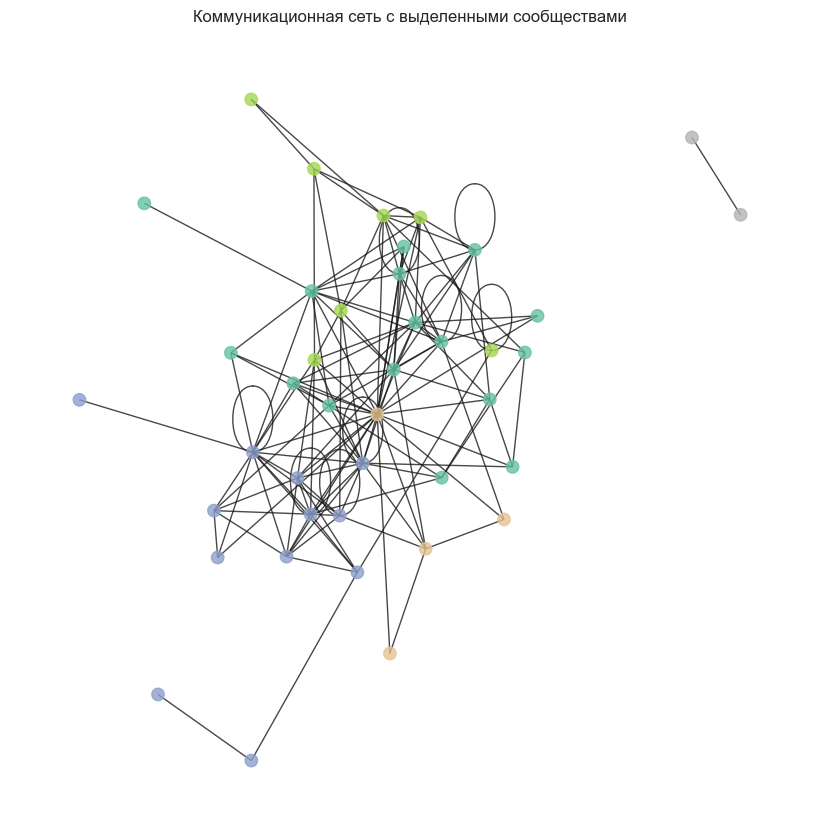

In [79]:
plt.figure(figsize=(8,8))

pos = nx.spring_layout(G_undirected, k=0.5)

colors = [community_map[node] for node in G_undirected.nodes()]

nx.draw(
    G_undirected,
    pos,
    node_color=colors,
    cmap=plt.cm.Set2,
    node_size=80,
    with_labels=False,
    alpha=0.8
)

plt.title("Коммуникационная сеть с выделенными сообществами")
plt.show()

### Вывод по анализу сообществ

Алгоритм выявил 5 сообществ различного размера

Наиболее крупное сообщество включает 16 участников и формирует ядро сети  
Второе по размеру сообщество насчитывает 12 участников и также тесно интегрировано в общую структуру

Оставшиеся сообщества существенно меньше  
Их можно интерпретировать как периферийные группы или локальные кластеры взаимодействия

Визуализация сети подтверждает наличие плотного центрального сегмента с несколькими пересекающимися связями  
При этом наблюдаются более компактные группы, частично отделённые от основного ядра

Некоторые участники располагаются на границе кластеров, что может указывать на их роль межгрупповых посредников

В целом структура сети демонстрирует сегментацию с выраженным ядром и несколькими периферийными сообществами  
Это подтверждает наличие внутренней организационной структуры коммуникаций

## 11. Анализ связей между сообществами

На данном этапе исследуется интенсивность коммуникаций между выявленными сообществами

Цель анализа:

- определить уровень взаимодействия между кластерами  
- выявить изолированные группы  
- определить, какие сообщества формируют ядро сети  

In [80]:
messages_with_comm = messages.merge(
    community_df.rename(columns={"participant": "sender", "community": "sender_comm"}),
    on="sender",
    how="left"
)

messages_with_comm = messages_with_comm.merge(
    community_df.rename(columns={"participant": "receiver", "community": "receiver_comm"}),
    on="receiver",
    how="left"
)

messages_with_comm.head()

,sender,comm_id,receiver,type,label,name,sub_type,timestamp,monitoring_type,findings,...,report_type,submission_date,jurisdiction_type,authority_level,coordination_type,operational_role,datetime,hour,sender_comm,receiver_comm
0,Sam,Event_Communication_370,Kelly,Event,Communication,NaN,Communication,2040-10-05 10:48:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2040-10-05 10:48:00,10,1,1
1,Kelly,Event_Communication_3,Sam,Event,Communication,NaN,Communication,2040-10-01 08:13:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2040-10-01 08:13:00,8,1,1
2,Kelly,Event_Communication_443,Sam,Event,Communication,NaN,Communication,2040-10-07 08:11:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2040-10-07 08:11:00,8,1,1
3,Nadia Conti,Event_Communication_331,Haacklee Harbor,Event,Communication,NaN,Communication,2040-10-05 09:45:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2040-10-05 09:45:00,9,0,3
4,Nadia Conti,Event_Communication_334,Oceanus City Council,Event,Communication,NaN,Communication,2040-10-05 09:49:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2040-10-05 09:49:00,9,0,1


In [81]:
community_matrix = (
    messages_with_comm
    .groupby(["sender_comm", "receiver_comm"])
    .size()
    .reset_index(name="count")
)

community_pivot = community_matrix.pivot(
    index="sender_comm",
    columns="receiver_comm",
    values="count"
).fillna(0)

community_pivot

receiver_comm,0,1,2,3,4
sender_comm,,,,,
0,126.0,21.0,14.0,33.0,0.0
1,20.0,140.0,32.0,13.0,0.0
2,12.0,23.0,55.0,5.0,0.0
3,25.0,10.0,4.0,13.0,0.0
4,0.0,0.0,0.0,0.0,38.0


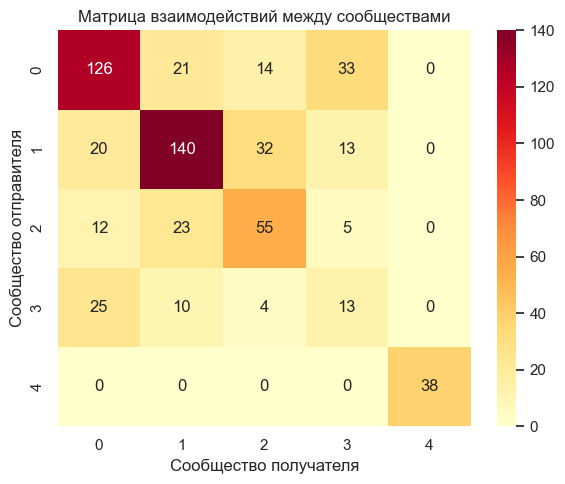

In [82]:
plt.figure(figsize=(6,5))

sns.heatmap(
    community_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Матрица взаимодействий между сообществами")
plt.xlabel("Сообщество получателя")
plt.ylabel("Сообщество отправителя")

plt.tight_layout()
plt.show()

### Вывод по анализу межкластерных взаимодействий

Матрица взаимодействий между сообществами показывает выраженную концентрацию сообщений внутри кластеров

Наибольшие значения наблюдаются на диагонали матрицы, что означает преобладание внутригрупповой коммуникации  
Сообщества 0 и 1 демонстрируют особенно высокую внутреннюю активность

Межкластерные взаимодействия присутствуют, но их интенсивность существенно ниже внутрикластерной  
Наиболее активный обмен наблюдается между сообществами 0 и 3, а также между 1 и 2

Сообщество 4 полностью изолировано от остальных  
Оно взаимодействует исключительно внутри своей группы, что указывает на автономный характер

В целом структура сети характеризуется выраженной сегментацией  
Существует центральное ядро из нескольких активно взаимодействующих сообществ и изолированный периферийный кластер

Это подтверждает наличие внутренней организационной структуры и частичной фрагментации коммуникационной системы

## 14. Анализ содержания сообщений

На данном этапе проводится анализ текстовой составляющей коммуникаций

Цель анализа:

- определить основные тематические акценты сообщений  
- выявить различия в содержании между крупнейшими сообществами  
- проверить, отражается ли структурная сегментация сети в тематике коммуникаций

In [84]:
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# приведение к нижнему регистру
messages["clean_text"] = (
    messages["content"]
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
)

# удаление стоп-слов
def preprocess(text):
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 3]
    return words

messages["tokens"] = messages["clean_text"].dropna().apply(preprocess)

In [85]:
all_words = []
for tokens in messages["tokens"].dropna():
    all_words.extend(tokens)

word_counts = Counter(all_words)

common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "count"]
)

common_words

,word,count
0,reef,378
1,nemo,304
2,harbor,182
3,equipment,181
4,need,152
5,mako,146
6,vessels,140
7,council,135
8,tomorrow,115
9,meeting,109


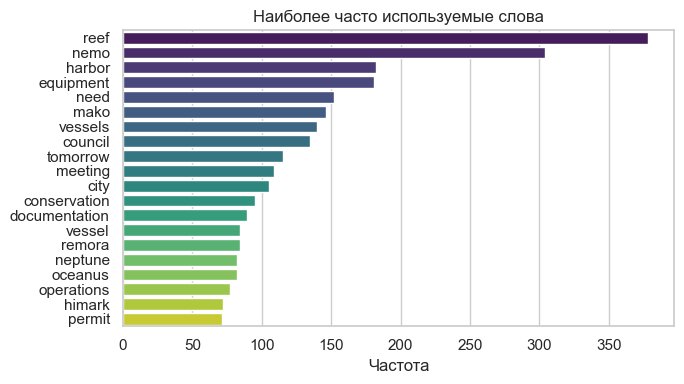

In [86]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=common_words,
    y="word",
    x="count",
    hue="word",
    palette="viridis",
    legend=False
)

plt.title("Наиболее часто используемые слова")
plt.xlabel("Частота")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [87]:
largest_comms = community_sizes.sort_values("size", ascending=False)["community"].head(2).tolist()
largest_comms

[0, 1]

In [88]:
messages_text = messages.merge(
    community_df.rename(columns={"participant": "sender", "community": "sender_comm"}),
    on="sender",
    how="left"
)

In [89]:
def top_words_for_comm(comm_id):
    words = []
    subset = messages_text[messages_text["sender_comm"] == comm_id]
    
    for tokens in subset["tokens"].dropna():
        words.extend(tokens)
        
    return Counter(words).most_common(10)

top_words_comm0 = top_words_for_comm(largest_comms[0])
top_words_comm1 = top_words_for_comm(largest_comms[1])

top_words_comm0, top_words_comm1

([('reef', 83),
  ('nemo', 77),
  ('equipment', 72),
  ('harbor', 71),
  ('remora', 71),
  ('mako', 69),
  ('need', 65),
  ('neptune', 62),
  ('team', 48),
  ('davis', 46)],
 [('reef', 202),
  ('nemo', 140),
  ('council', 77),
  ('vessels', 76),
  ('equipment', 69),
  ('guardians', 66),
  ('city', 64),
  ('green', 64),
  ('guardian', 59),
  ('oceanus', 56)])

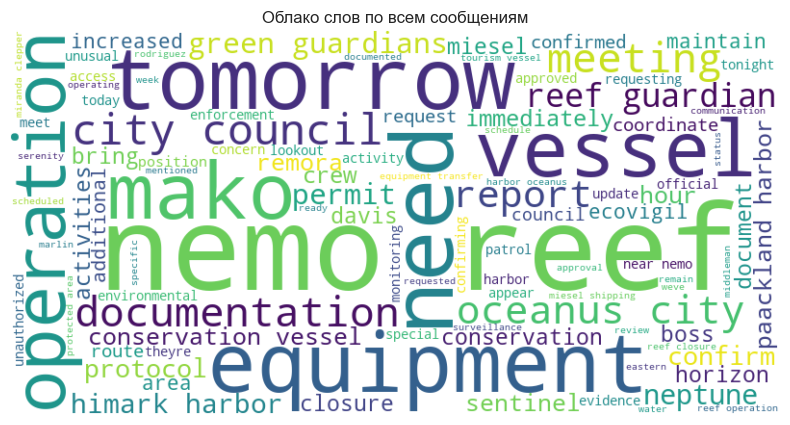

In [91]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# объединяем очищенные слова
text_for_cloud = " ".join(all_words)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis",
    max_words=100
).generate(text_for_cloud)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Облако слов по всем сообщениям")
plt.show()

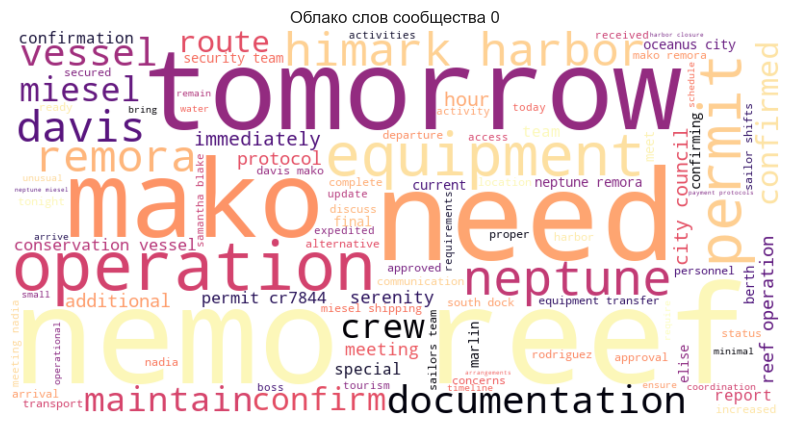

In [92]:
comm_id = largest_comms[0]

comm_words = []
subset = messages_text[messages_text["sender_comm"] == comm_id]

for tokens in subset["tokens"].dropna():
    comm_words.extend(tokens)

text_comm = " ".join(comm_words)

wordcloud_comm = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="magma",
    max_words=100
).generate(text_comm)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_comm, interpolation="bilinear")
plt.axis("off")
plt.title(f"Облако слов сообщества {comm_id}")
plt.show()

### Вывод по анализу содержания сообщений

Частотный анализ и облако слов показывают, что коммуникации преимущественно сосредоточены вокруг операционной и организационной тематики

Наиболее часто употребляются слова, связанные с:
- морской инфраструктурой и локациями (harbor, vessel, oceanus, reef)
- оборудованием и операциями (equipment, operation, crew)
- административными процедурами (permit, documentation, confirm)
- координацией действий (meeting, request, maintain)

Это указывает на функционально-деловой характер коммуникаций

Облако слов по всей сети демонстрирует доминирование терминов, связанных с управлением ресурсами, перемещением судов и согласованием действий

Анализ крупнейшего сообщества подтверждает концентрацию слов, связанных с оперативным управлением, оборудованием и координацией действий

Тематика сообщений внутри ядра сети носит преимущественно управленческий и координационный характер

Содержательный анализ согласуется со структурным анализом сети  
Кластеры формируются не случайно, а отражают функциональные направления взаимодействия

Таким образом, коммуникационная сеть демонстрирует не только структурную сегментацию, но и тематическую специализацию групп

### 15. Тематический анализ сообщений по сообществам

После выявления сообществ в коммуникационной сети можно проанализировать содержательную сторону взаимодействий

Цель данного этапа - определить, отличаются ли темы сообщений между сообществами и существуют ли характерные тематические направления внутри отдельных групп участников

Для этого для каждого сообщества строится облако слов на основе текста сообщений, связанных с участниками данного сообщества

In [104]:
node_community = {}

for i, comm in enumerate(communities):
    for node in comm:
        node_community[node] = i

community_df = pd.DataFrame(
    list(node_community.items()),
    columns=["participant", "community"]
)

community_df.head()

,participant,community
0,Davis,0
1,Nadia Conti,0
2,Neptune,0
3,Elise,0
4,Himark Harbor,0


In [109]:
messages_comm = messages.merge(
    community_df,
    left_on="sender",
    right_on="participant",
    how="left"
).rename(columns={"community": "sender_community"})

In [110]:
messages_comm = messages_comm.merge(
    community_df,
    left_on="receiver",
    right_on="participant",
    how="left",
    suffixes=("", "_receiver")
).rename(columns={"community": "receiver_community"})

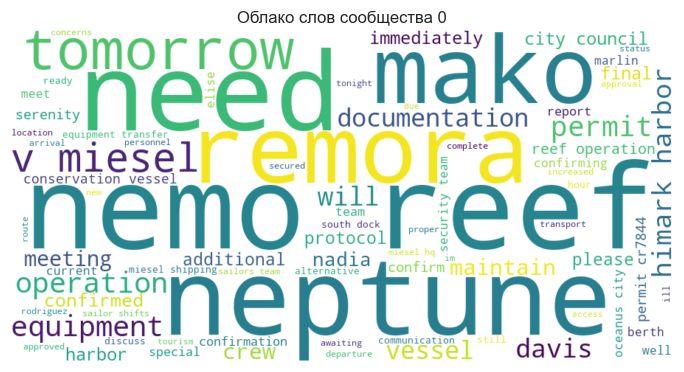

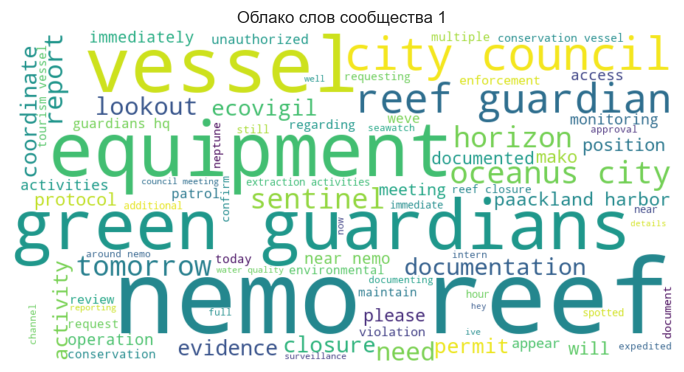

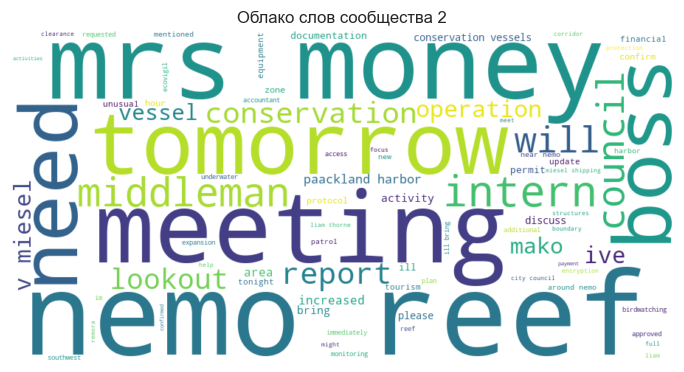

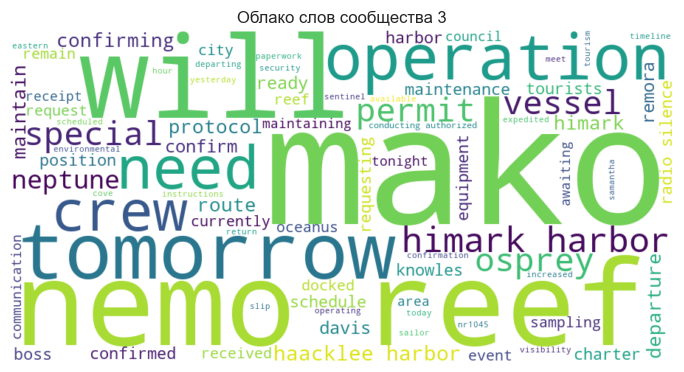

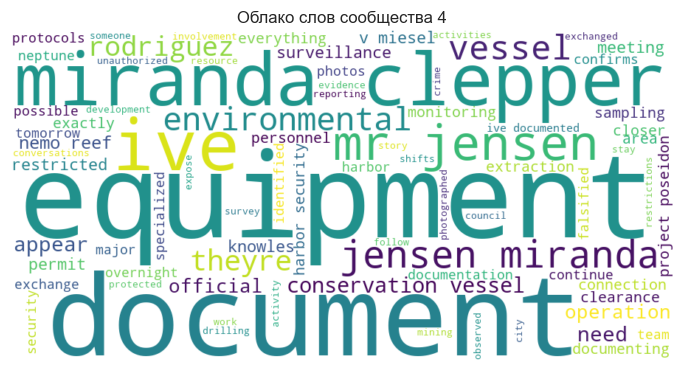

In [111]:
communities_list = sorted(messages_comm["sender_community"].dropna().unique())

for c in communities_list:
    text = " ".join(
        messages_comm.loc[messages_comm["sender_community"] == c, "clean_text"]
        .dropna()
        .astype(str)
    )

    if len(text) < 20:
        continue

    wc = WordCloud(
        width=900,
        height=450,
        background_color="white",
        colormap="viridis",
        max_words=80
    ).generate(text)

    plt.figure(figsize=(7, 3.8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Облако слов сообщества {c}")
    plt.tight_layout()
    plt.show()

**Сообщество 0** характеризуется коммуникациями, связанными с операционной координацией и логистикой судов

В сообщениях часто встречаются слова reef, nemo, neptune, vessel, equipment, harbor и permit  
Это указывает на обсуждение перемещений судов, оборудования и работы в районе рифа Nemo

Также заметна активность участников Mako, Remora, Neptune и V. Miesel, что говорит о координации морских операций и подготовке действий на воде

В целом данное сообщество отражает рабочую коммуникацию, связанную с **операционным управлением и организацией морских задач**

**Сообщество 1** связано с вопросами экологического мониторинга и административного контроля.

Ключевые слова включают green guardians, vessel, equipment, reef guardian, city council, permit и documentation  
Это указывает на обсуждение разрешений, проверок и экологических процедур

В коммуникациях активно участвуют организации, отвечающие за охрану окружающей среды и контроль деятельности в районе рифа

Таким образом данное сообщество отражает взаимодействие между **экологическими организациями и административными структурами**

**Сообщество 2** включает участников, связанных с координацией встреч, отчётов и обсуждением текущих действий

Наиболее частые слова - meeting, tomorrow, report, conservation, lookout и operations

Это указывает на коммуникации, связанные с планированием мероприятий, обменом информацией и обсуждением текущих задач

Данное сообщество играет роль **координационного уровня, где происходит обсуждение и согласование дальнейших действий**

**Сообщество 3** связано с обсуждением конкретных операционных задач и планирования работ

В сообщениях часто встречаются слова mako, crew, operation, permit, vessel, harbor и schedule

Это говорит о координации экипажей, планировании операций и подготовке судов к выходу

Коммуникации в этом сообществе носят **прикладной характер и связаны с непосредственной организацией деятельности на воде**

**Сообщество 4** заметно отличается от остальных кластеров

В сообщениях доминируют слова equipment, document, environmental, survey и extraction
Также часто упоминаются Miranda Jensen и Rodriguez

Тематика сообщений связана с документацией, экологическими исследованиями и сбором данных

Особенностью данного сообщества является высокая внутренняя связность и практически полное отсутствие коммуникаций с другими группами участников

Это может указывать на **специализированную команду или рабочую группу, выполняющую отдельную задачу** и взаимодействующую преимущественно внутри своей команды

### Общий вывод по тематике сообществ

Анализ облаков слов показывает, что сообщества в коммуникационной сети отличаются не только структурой связей, но и тематикой сообщений

Отдельные группы участников специализируются на различных аспектах деятельности — операционной координации судов, экологическом мониторинге, административных процедурах и планировании работ

Это подтверждает, что выявленные сообщества отражают реальные функциональные группы внутри коммуникационной сети

Особый интерес представляет небольшое сообщество, в котором участники взаимодействуют практически исключительно между собой
Тематика сообщений в этой группе связана с документацией и экологическими исследованиями, что может указывать на специализированную рабочую команду, выполняющую отдельный блок задач

Таким образом структура сети отражает не только интенсивность коммуникаций, но и функциональное разделение ролей между участниками

## Итоговые выводы исследования

В начале работы были сформулированы несколько гипотез о структуре и содержании коммуникационной сети

**H1: В сети существует центральное ядро с доминирующими участниками**  
Эта гипотеза подтверждается  
Анализ показал, что в сети присутствует группа наиболее активных участников, обладающих наибольшим числом связей и занимающих центральное положение в структуре коммуникаций

**H2: Сеть разделена на устойчивые сообщества с преобладанием внутригрупповых взаимодействий**  
Гипотеза также подтверждается  
Алгоритм выделения сообществ выявил несколько кластеров участников, внутри которых коммуникации происходят значительно чаще, чем между различными группами

**H3: В сети есть посредники, соединяющие разные сообщества**  
Гипотеза подтверждается  
Были выявлены участники с высокой центральностью посредничества, через которых проходит значительная часть межгрупповых коммуникаций  
Такие узлы играют важную роль в поддержании связности сети и передаче информации между различными кластерами

**H4: Тематика сообщений различается между крупнейшими сообществами**  
Гипотеза подтверждается частично  
Анализ содержания сообщений показал, что коммуникации носят преимущественно деловой и координационный характер  
При этом в отдельных сообществах наблюдается концентрация вокруг определённых тем, что может указывать на функциональную специализацию групп

Дополнительный временной анализ показал, что коммуникационная активность сосредоточена преимущественно в утренние рабочие часы и значительно снижается в выходные дни  
Это подтверждает предположение о том, что рассматриваемая сеть отражает прежде всего рабочие процессы и координацию операционной деятельности

Также было выявлено небольшое сообщество участников, взаимодействующих преимущественно между собой и обсуждающих специализированные вопросы, связанные с документацией и экологическими исследованиями  
Это может указывать на существование отдельной рабочей группы, выполняющей специфические задачи в рамках общей системы коммуникаций

В целом коммуникационная сеть имеет умеренно централизованную структуру, включает несколько устойчивых кластеров и характеризуется наличием ключевых участников, влияющих на распределение информационных потоков